# Destination Divergence — Group vs. Solo Riders
**NYC Citi Bike — July & August 2025**

For trips originating at the same station, do group trips end at
systematically different destinations than solo trips — suggesting
that social context changes where people ride?

**Pipeline:**
1. Load co-trip-tagged trips and station clusters
2. Build per-origin destination distributions for group vs. solo trips
3. Quantify divergence via Jensen-Shannon distance
4. Chi-squared tests on high-volume stations
5. Characterise high- and low-divergence stations
6. Map divergence across NYC
7. Archetype-level divergence summary
8. Top destination shifts — which destinations do groups over/under-index on?

## 0. Setup

In [0]:
%pip install folium tqdm

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import pyspark.sql.functions as F
from pyspark.sql.functions import col, count, sum as spark_sum, lit
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.spatial.distance import jensenshannon
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


def cramers_v(contingency_table):
    """Compute Cramér's V effect size from a contingency table (numpy array).
    Ranges from 0 (no association) to 1 (perfect association).
    More informative than χ² p-values at large sample sizes.""" 
    chi2, _, _, _ = chi2_contingency(contingency_table)
    n = contingency_table.sum()
    r, k = contingency_table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))



## 1. Load tables

In [0]:
trips = spark.table("citibike.trips_cotrip_tagged")
clusters = spark.table("citibike.station_clusters")

# Join archetype labels onto start station
start_cl = clusters.select(
    col("station_name").alias("start_station_name"),
    col("cluster").alias("start_cluster"),
    col("archetype").alias("start_archetype"),
    col("lat").alias("start_lat"),
    col("lng").alias("start_lng"),
)

df = trips.join(start_cl, on="start_station_name", how="left")

print(f"Total trips: {df.count():,}")

Total trips: 10,073,076


## 2. Build per-origin destination distributions (Spark)

For each (origin station, destination station) pair, count group and
solo trips separately. This runs entirely in Spark on the full dataset.

In [0]:
od_counts = (
    df
    .filter(col("start_station_name").isNotNull() & col("end_station_name").isNotNull())
    .groupBy("start_station_name", "end_station_name", "is_cotrip")
    .agg(count("*").alias("trip_count"))
)

# Pivot so each row is (origin, destination) with columns for solo and group counts
od_wide = (
    od_counts
    .groupBy("start_station_name", "end_station_name")
    .pivot("is_cotrip", [0, 1])
    .agg(F.sum("trip_count"))
    .fillna(0)
    .withColumnRenamed("0", "solo_trips")
    .withColumnRenamed("1", "group_trips")
    .withColumn("total_trips", col("solo_trips") + col("group_trips"))
)

print(f"OD pairs: {od_wide.count():,}")
od_wide.show(5)

OD pairs: 972,624
+--------------------+--------------------+----------+-----------+-----------+
|  start_station_name|    end_station_name|solo_trips|group_trips|total_trips|
+--------------------+--------------------+----------+-----------+-----------+
|E 58 St & 1 Ave (...|      31 Ave & 30 St|        26|          3|         29|
|     W 49 St & 8 Ave|W 84 St & Amsterd...|         6|          3|          9|
|  E 91 St & Park Ave|  E 47 St & Park Ave|        52|          1|         53|
|  E 91 St & Park Ave|W 84 St & Amsterd...|        32|          3|         35|
|     W 49 St & 8 Ave|   Bergen St & 4 Ave|         1|          0|          1|
+--------------------+--------------------+----------+-----------+-----------+
only showing top 5 rows


## 3. Collect to pandas & compute per-origin totals

The OD-pair table is manageable in memory (~50-100K rows). We filter to
origin stations with enough group trips to make divergence meaningful.

In [0]:
od_pdf = od_wide.toPandas()

# Per-origin volume
origin_stats = od_pdf.groupby("start_station_name").agg(
    total_solo=("solo_trips", "sum"),
    total_group=("group_trips", "sum"),
    n_destinations=("end_station_name", "nunique"),
).reset_index()
origin_stats["total"] = origin_stats["total_solo"] + origin_stats["total_group"]

# Filter: need meaningful group AND solo volume for a fair comparison.
# Require at least 50 group trips and 200 solo trips at an origin.
# QUESTION - good way to do it or do percentile base like in orginial clustering notebook
MIN_GROUP = 50
MIN_SOLO = 200
eligible = origin_stats[
    (origin_stats["total_group"] >= MIN_GROUP) &
    (origin_stats["total_solo"] >= MIN_SOLO)
].copy()

print(f"Stations with >= {MIN_GROUP} group + >= {MIN_SOLO} solo trips: {len(eligible)}")
print(f"These cover {eligible['total'].sum():,} / {origin_stats['total'].sum():,} trips "
      f"({100 * eligible['total'].sum() / origin_stats['total'].sum():.1f}%)")

Stations with >= 50 group + >= 200 solo trips: 1808
These cover 9,930,416 / 10,073,076 trips (98.6%)


## 4. Jensen-Shannon divergence per origin station

For each eligible origin, we build normalised destination probability
vectors for group and solo trips, then compute JSD. A value of 0 means
identical distributions; 1 means completely disjoint support.

We use the **base-2 log** convention so JSD is bounded in [0, 1].

In [0]:
eligible_stations = set(eligible["start_station_name"])
od_eligible = od_pdf[od_pdf["start_station_name"].isin(eligible_stations)].copy()

# Build a union destination vocabulary per origin so both vectors have the
# same length (destinations absent from one side get probability 0).

results = []
od_eleg_grouped = od_eligible.groupby("start_station_name")

for station, grp in tqdm(od_eleg_grouped, total=len(od_eleg_grouped), desc="Iterating over OD groups"):
    solo_dist = grp.set_index("end_station_name")["solo_trips"]
    group_dist = grp.set_index("end_station_name")["group_trips"]

    # Align on full destination set
    all_dests = solo_dist.index.union(group_dist.index)
    p_solo = solo_dist.reindex(all_dests, fill_value=0).values.astype(float)
    p_group = group_dist.reindex(all_dests, fill_value=0).values.astype(float)

    # Normalise to probability distributions
    p_solo = p_solo / p_solo.sum()
    p_group = p_group / p_group.sum()

    jsd = jensenshannon(p_solo, p_group, base=2)

    results.append({
        "start_station_name": station,
        "jsd": jsd,
        "n_solo": int(solo_dist.sum()),
        "n_group": int(group_dist.sum()),
        "n_destinations": len(all_dests),
    })

jsd_df = pd.DataFrame(results)
print(f"JSD computed for {len(jsd_df)} stations")
print(jsd_df["jsd"].describe())

Iterating over OD groups: 100%|██████████| 1808/1808 [02:34<00:00, 11.69it/s]

JSD computed for 1808 stations
count    1808.000000
mean        0.541462
std         0.110153
min         0.170505
25%         0.450163
50%         0.548255
75%         0.630328
max         0.801803
Name: jsd, dtype: float64


## 5. JSD distribution

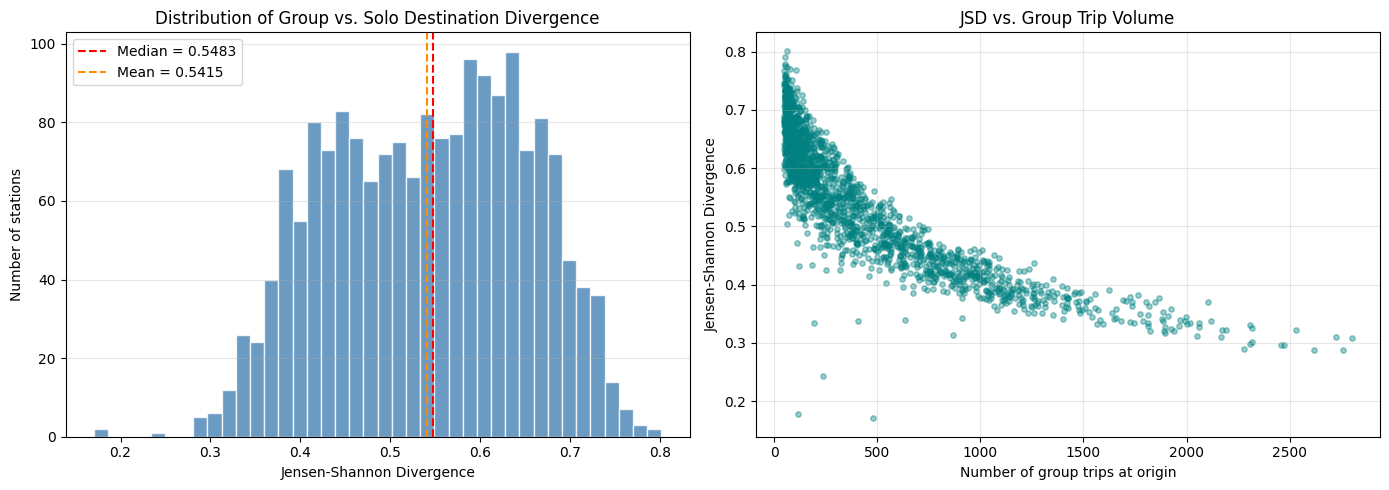

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(jsd_df["jsd"], bins=40, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(jsd_df["jsd"].median(), color="red", linestyle="--",
           label=f'Median = {jsd_df["jsd"].median():.4f}')
ax.axvline(jsd_df["jsd"].mean(), color="darkorange", linestyle="--",
           label=f'Mean = {jsd_df["jsd"].mean():.4f}')
ax.set_xlabel("Jensen-Shannon Divergence")
ax.set_ylabel("Number of stations")
ax.set_title("Distribution of Group vs. Solo Destination Divergence")
ax.legend()
ax.grid(axis="y", alpha=0.3)

ax = axes[1]
ax.scatter(jsd_df["n_group"], jsd_df["jsd"], alpha=0.4, s=15, color="teal")
ax.set_xlabel("Number of group trips at origin")
ax.set_ylabel("Jensen-Shannon Divergence")
ax.set_title("JSD vs. Group Trip Volume")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Chi-squared tests on high-volume stations

For the top stations by volume, run a χ² test of independence on the
(destination × group/solo) contingency table. This gives a formal
p-value per station for whether the destination mix differs.

In [0]:
TOP_N_CHI2 = 100  # test the busiest stations

chi2_stations = (
    jsd_df
    .nlargest(TOP_N_CHI2, "n_group")
    .copy()
)

chi2_results = []
for _, row in chi2_stations.iterrows():
    station = row["start_station_name"]
    sub = od_eligible[od_eligible["start_station_name"] == station]

    table = sub[["solo_trips", "group_trips"]].values
    # Drop rows where both are zero (shouldn't happen, but safety)
    table = table[table.sum(axis=1) > 0]

    if table.shape[0] < 2:
        continue

    chi2, pval, dof, _ = chi2_contingency(table)
    cv = cramers_v(table)
# print(f"\nχ² = {chi2:.1f}, p = {pval:.2e}, dof = {dof}")
# print(f"Cramér's V = {cv:.4f}  (< 0.1 = negligible, 0.1-0.3 = small, 0.3-0.5 = medium, > 0.5 = large)")
    chi2_results.append({
        "start_station_name": station,
        "chi2": chi2,
        "p_value": pval,
        "dof": dof,
        "jsd": row["jsd"],
        "cv": cv,
    })

chi2_df = pd.DataFrame(chi2_results)

# Bonferroni correction
alpha = 0.05
chi2_df["significant"] = chi2_df["p_value"] < (alpha / len(chi2_df))

n_sig = chi2_df["significant"].sum()
print(f"Tested: {len(chi2_df)} stations")
print(f"Significant after Bonferroni correction (α={alpha}): {n_sig} ({100*n_sig/len(chi2_df):.1f}%)")
print(f"\nLowest p-values:")
print(chi2_df.nsmallest(10, "p_value")[
    ["start_station_name", "chi2", "p_value", "jsd", "significant", "cv"]
].to_string(index=False))
print(f"\nHighest Cramer's V values:")
print(chi2_df.nlargest(10, "cv")[
    ["start_station_name", "chi2", "p_value", "jsd", "significant", "cv"]
].to_string(index=False))

Tested: 100 stations
Significant after Bonferroni correction (α=0.05): 82 (82.0%)

Lowest p-values:
            start_station_name        chi2      p_value      jsd  significant       cv
              W 30 St & 10 Ave 1233.061385 7.734589e-19 0.322052         True 0.215767
      Pier 61 at Chelsea Piers 1276.251987 8.701795e-17 0.288487         True 0.195336
         West St & Chambers St 1315.401919 2.241867e-16 0.307664         True 0.198209
              11 Ave & W 27 St 1164.542628 3.420385e-16 0.377672         True 0.255115
               W 24 St & 7 Ave 1209.173267 3.610729e-15 0.337383         True 0.231569
              11 Ave & W 41 St 1127.122786 1.110666e-13 0.309373         True 0.199558
         Greenwich Ave & 8 Ave 1239.938744 8.210617e-13 0.327710         True 0.227701
              W 22 St & 10 Ave 1093.829989 1.832157e-12 0.361209         True 0.248054
Metropolitan Ave & Bedford Ave 1497.127844 2.801040e-12 0.370380         True 0.243606
        Hanson Pl & Ashland Pl

## 7. Highest and lowest divergence stations

In [0]:
# Merge coordinates and archetype for context
jsd_full = jsd_df.merge(
    eligible[["start_station_name", "total_solo", "total_group"]],
    on="start_station_name",
    how="left",
)

# Attach archetype via clusters table
clusters_pdf = clusters.toPandas()
jsd_full = jsd_full.merge(
    clusters_pdf[["station_name", "archetype", "lat", "lng"]],
    left_on="start_station_name",
    right_on="station_name",
    how="left",
).drop(columns=["station_name"], errors="ignore")

print("\n--- TOP 15 HIGHEST DIVERGENCE (groups go very different places than solos) ---")
top_div = jsd_full.nlargest(15, "jsd")
for _, r in top_div.iterrows():
    print(f"  JSD={r['jsd']:.4f}  {r['start_station_name']:45s}  "
          f"arch={str(r.get('archetype','?')):25s}  "
          f"group={r['n_group']:>5,}  solo={r['n_solo']:>6,}")

print("\n--- TOP 15 LOWEST DIVERGENCE (groups go to same places as solos) ---")
low_div = jsd_full.nsmallest(15, "jsd")
for _, r in low_div.iterrows():
    print(f"  JSD={r['jsd']:.4f}  {r['start_station_name']:45s}  "
          f"arch={str(r.get('archetype','?')):25s}  "
          f"group={r['n_group']:>5,}  solo={r['n_solo']:>6,}")


--- TOP 15 HIGHEST DIVERGENCE (groups go very different places than solos) ---
  JSD=0.8018  Sumpter St & Fulton St                         arch=Inner Residential          group=   62  solo=   608
  JSD=0.7911  Sterling Pl & Rochester Ave                    arch=Inner Residential          group=   55  solo=   637
  JSD=0.7792  Edgecombe Ave & W 150 St                       arch=Outer Residential          group=   53  solo=   569
  JSD=0.7758  Metropolitan Ave & Bedford Ave                 arch=High Traffic Hubs          group=   54  solo=   495
  JSD=0.7732  Jerome Ave & Anderson Ave                      arch=Nightlife / Late Evening   group=   62  solo=   634
  JSD=0.7696  Carlton Ave & St Marks Ave                     arch=High Traffic Hubs          group=   76  solo= 1,013
  JSD=0.7681  Park Pl & Utica Ave                            arch=Inner Residential          group=  108  solo= 1,057
  JSD=0.7676  Amsterdam Ave & W 183 St                       arch=Outer Residential          g

## 8. Map divergence onto NYC

Each station dot is coloured by its JSD — hot colours indicate stations
where social context changes destination choice the most.

In [0]:
import folium
from branca.colormap import LinearColormap

map_df = jsd_full.dropna(subset=["lat", "lng"])
map_df = map_df[(map_df["lat"] > 40.5) & (map_df["lat"] < 41.0)]

cmap = LinearColormap(
    ["#2166ac", "#f7f7f7", "#b2182b"],
    vmin=map_df["jsd"].quantile(0.05),
    vmax=map_df["jsd"].quantile(0.95),
    caption="Jensen-Shannon Divergence (group vs. solo destinations)",
)

m = folium.Map(location=[40.735, -73.99], zoom_start=12, tiles="cartodbpositron")

for _, row in map_df.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lng"]],
        radius=4,
        color=cmap(row["jsd"]),
        fill=True,
        fill_color=cmap(row["jsd"]),
        fill_opacity=0.8,
        popup=(
            f"{row['start_station_name']}<br>"
            f"JSD: {row['jsd']:.4f}<br>"
            f"Archetype: {row.get('archetype', '?')}<br>"
            f"Group trips: {row['n_group']:,}<br>"
            f"Solo trips: {row['n_solo']:,}"
        ),
    ).add_to(m)

m.add_child(cmap)
m

## 9. Divergence by station archetype

Does archetype predict divergence? Commuter hubs might show low JSD
(everyone goes to the office regardless of company) while tourist/nightlife
stations might show high JSD (groups choose fun destinations).

In [0]:
arch_jsd = (
    jsd_full
    .dropna(subset=["archetype"])
    .groupby("archetype")
    .agg(
        median_jsd=("jsd", "median"),
        mean_jsd=("jsd", "mean"),
        std_jsd=("jsd", "std"),
        n_stations=("jsd", "count"),
    )
    .sort_values("median_jsd", ascending=False)
)

print(arch_jsd.to_string())

                                median_jsd  mean_jsd   std_jsd  n_stations
archetype                                                                 
Outer Residential                 0.635773  0.632975  0.064121         287
Inner Residential                 0.606439  0.597831  0.084059         370
Nightlife / Late Evening          0.600838  0.574180  0.107569         135
Tourist / Recreational            0.491801  0.492836  0.119039         112
High Traffic Hubs                 0.480979  0.493147  0.095902         728
Commuter Hub / Commercial Area    0.452623  0.479431  0.106032         176


/home/spark-17fb9703-d908-4194-a833-56/.ipykernel/3487/command-6329382136726868-4208375496:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_arch, labels=archetypes_sorted, patch_artist=True, vert=True)


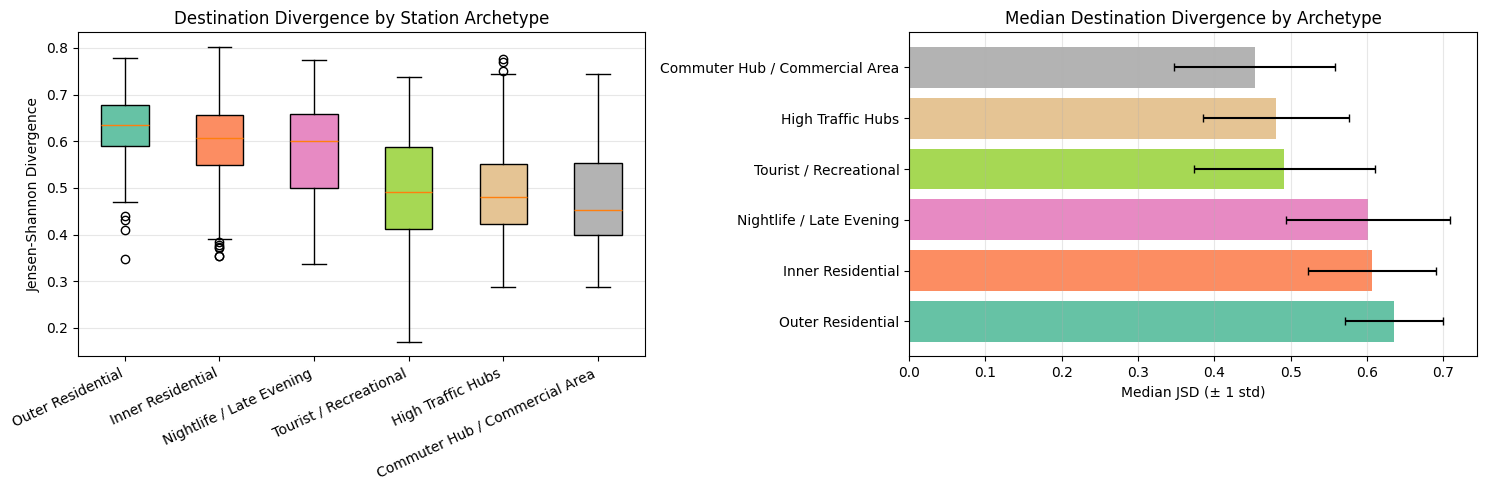

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Box plot
ax = axes[0]
archetypes_sorted = arch_jsd.index.tolist()
data_by_arch = [
    jsd_full[jsd_full["archetype"] == a]["jsd"].values
    for a in archetypes_sorted
]
bp = ax.boxplot(data_by_arch, labels=archetypes_sorted, patch_artist=True, vert=True)
colors = plt.cm.Set2(np.linspace(0, 1, len(archetypes_sorted)))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
ax.set_ylabel("Jensen-Shannon Divergence")
ax.set_title("Destination Divergence by Station Archetype")
ax.set_xticklabels(archetypes_sorted, rotation=25, ha="right")
ax.grid(axis="y", alpha=0.3)

# Bar plot of medians
ax = axes[1]
ax.barh(arch_jsd.index, arch_jsd["median_jsd"], color=colors, xerr=arch_jsd["std_jsd"], capsize=3)
ax.set_xlabel("Median JSD (± 1 std)")
ax.set_title("Median Destination Divergence by Archetype")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Top destination shifts at high-divergence stations

For the stations with highest JSD, show which specific destinations
groups over-index and under-index on compared to solo riders. This
grounds the divergence score in concrete geography.

"Lift" = (group share of destination) / (solo share of destination).
Lift > 1 means groups favour that destination; < 1 means solos do.

In [0]:
TOP_STATIONS = 10
DEST_PER_STATION = 5

top_stations = jsd_full.nlargest(TOP_STATIONS, "jsd")["start_station_name"].tolist()

for station in top_stations:
    sub = od_eligible[od_eligible["start_station_name"] == station].copy()
    total_solo = sub["solo_trips"].sum()
    total_group = sub["group_trips"].sum()

    if total_solo == 0 or total_group == 0:
        continue

    sub["solo_share"] = sub["solo_trips"] / total_solo
    sub["group_share"] = sub["group_trips"] / total_group
    sub["lift"] = sub["group_share"] / sub["solo_share"].replace(0, np.nan)
    sub["share_diff"] = sub["group_share"] - sub["solo_share"]

    jsd_val = jsd_full.loc[jsd_full["start_station_name"] == station, "jsd"].values[0]

    # Top group over-indexed destinations (highest lift with meaningful volume)
    sub_with_volume = sub[sub["group_trips"] >= 3]
    top_group = sub_with_volume.nlargest(DEST_PER_STATION, "share_diff")
    top_solo = sub_with_volume.nsmallest(DEST_PER_STATION, "share_diff")

    print(f"\n{'='*80}")
    print(f"  {station}  (JSD={jsd_val:.4f})")
    print(f"  Group trips: {total_group:,}  |  Solo trips: {total_solo:,}")
    print(f"{'='*80}")
    print(f"  GROUPS OVER-INDEX (go here more than solos):")
    for _, r in top_group.iterrows():
        print(f"    → {r['end_station_name']:40s}  "
              f"group={r['group_share']:.1%}  solo={r['solo_share']:.1%}  "
              f"lift={r['lift']:.1f}x")
    print(f"  GROUPS UNDER-INDEX (solos go here more):")
    for _, r in top_solo.iterrows():
        print(f"    → {r['end_station_name']:40s}  "
              f"group={r['group_share']:.1%}  solo={r['solo_share']:.1%}  "
              f"lift={r['lift']:.1f}x")


  Sumpter St & Fulton St  (JSD=0.8018)
  Group trips: 62  |  Solo trips: 608
  GROUPS OVER-INDEX (go here more than solos):
    → Lincoln Pl & Classon Ave                  group=4.8%  solo=0.0%  lift=nanx
    → Halsey St & Ralph Ave                     group=4.8%  solo=0.3%  lift=14.7x
    → Monroe St & Tompkins Ave                  group=4.8%  solo=1.5%  lift=3.3x
  GROUPS UNDER-INDEX (solos go here more):
    → Monroe St & Tompkins Ave                  group=4.8%  solo=1.5%  lift=3.3x
    → Halsey St & Ralph Ave                     group=4.8%  solo=0.3%  lift=14.7x
    → Lincoln Pl & Classon Ave                  group=4.8%  solo=0.0%  lift=nanx

  Sterling Pl & Rochester Ave  (JSD=0.7911)
  Group trips: 55  |  Solo trips: 637
  GROUPS OVER-INDEX (go here more than solos):
    → Chauncey St & Malcolm X Blvd              group=5.5%  solo=0.8%  lift=6.9x
  GROUPS UNDER-INDEX (solos go here more):
    → Chauncey St & Malcolm X Blvd              group=5.5%  solo=0.8%  lift=6.9x

  Edgeco

## 11. Aggregate destination-type shift: group vs. solo

At the system level, do group trips shift destination archetype mix
compared to solo trips? Aggregates across all origins to show the
overall "social pull" toward certain neighbourhood types.

In [0]:
# Join destination archetype onto OD pairs
end_cl_pdf = clusters_pdf[["station_name", "archetype"]].rename(
    columns={"station_name": "end_station_name", "archetype": "end_archetype"}
)

od_with_arch = od_eligible.merge(end_cl_pdf, on="end_station_name", how="left")
od_with_arch = od_with_arch.dropna(subset=["end_archetype"])

# System-wide destination mix by rider type
dest_mix = od_with_arch.groupby("end_archetype")[["solo_trips", "group_trips"]].sum()
dest_mix["solo_share"] = dest_mix["solo_trips"] / dest_mix["solo_trips"].sum()
dest_mix["group_share"] = dest_mix["group_trips"] / dest_mix["group_trips"].sum()
dest_mix["lift"] = dest_mix["group_share"] / dest_mix["solo_share"]

print(dest_mix[["solo_share", "group_share", "lift"]].sort_values("lift", ascending=False).to_string())

                                solo_share  group_share      lift
end_archetype                                                    
Nightlife / Late Evening          0.070607     0.073407  1.039646
High Traffic Hubs                 0.550620     0.557959  1.013329
Outer Residential                 0.040896     0.041187  1.007112
Tourist / Recreational            0.080826     0.080811  0.999813
Inner Residential                 0.101694     0.100978  0.992958
Commuter Hub / Commercial Area    0.155356     0.145658  0.937575


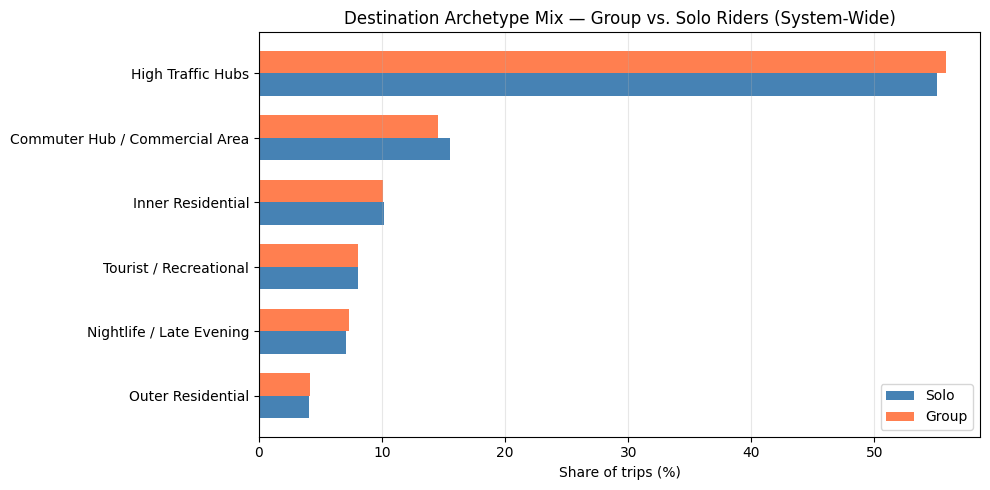

In [0]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(dest_mix))
w = 0.35
dest_mix_sorted = dest_mix.sort_values("group_share", ascending=True)

ax.barh(x - w/2, dest_mix_sorted["solo_share"] * 100, w, label="Solo", color="steelblue")
ax.barh(x + w/2, dest_mix_sorted["group_share"] * 100, w, label="Group", color="coral")

ax.set_yticks(x)
ax.set_yticklabels(dest_mix_sorted.index)
ax.set_xlabel("Share of trips (%)")
ax.set_title("Destination Archetype Mix — Group vs. Solo Riders (System-Wide)")
ax.legend()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Weekday vs. weekend divergence

Does the group/solo destination gap widen on weekends (leisure context)
compared to weekdays (utilitarian context)?

In [0]:
# Need to re-aggregate with day type — go back to Spark
od_daytype = (
    df
    .filter(col("start_station_name").isNotNull() & col("end_station_name").isNotNull())
    .groupBy("start_station_name", "end_station_name", "is_cotrip", "is_weekend")
    .agg(count("*").alias("trip_count"))
)

od_dt_wide = (
    od_daytype
    .groupBy("start_station_name", "end_station_name", "is_weekend")
    .pivot("is_cotrip", [0, 1])
    .agg(F.sum("trip_count"))
    .fillna(0)
    .withColumnRenamed("0", "solo_trips")
    .withColumnRenamed("1", "group_trips")
    .toPandas()
)

# Compute JSD per station × day type
jsd_by_daytype = []
od_dt_wide_grouped = od_dt_wide.groupby(["start_station_name", "is_weekend"])

for (station, is_we), grp in tqdm(od_dt_wide_grouped, total=len(od_dt_wide_grouped), desc="Iterating over OD groups - weekends"):
    if station not in eligible_stations:
        continue
    if grp["group_trips"].sum() < 20 or grp["solo_trips"].sum() < 50:
        continue

    solo_dist = grp.set_index("end_station_name")["solo_trips"]
    group_dist = grp.set_index("end_station_name")["group_trips"]
    all_dests = solo_dist.index.union(group_dist.index)

    p_solo = solo_dist.reindex(all_dests, fill_value=0).values.astype(float)
    p_group = group_dist.reindex(all_dests, fill_value=0).values.astype(float)
    p_solo = p_solo / p_solo.sum()
    p_group = p_group / p_group.sum()

    jsd_by_daytype.append({
        "start_station_name": station,
        "is_weekend": is_we,
        "jsd": jensenshannon(p_solo, p_group, base=2),
    })

jsd_dt_df = pd.DataFrame(jsd_by_daytype)
jsd_dt_df["day_label"] = jsd_dt_df["is_weekend"].map({0: "Weekday", 1: "Weekend"})

Iterating over OD groups - weekends: 100%|██████████| 4319/4319 [05:19<00:00, 13.51it/s]


Stations with higher weekend divergence: 98.9%


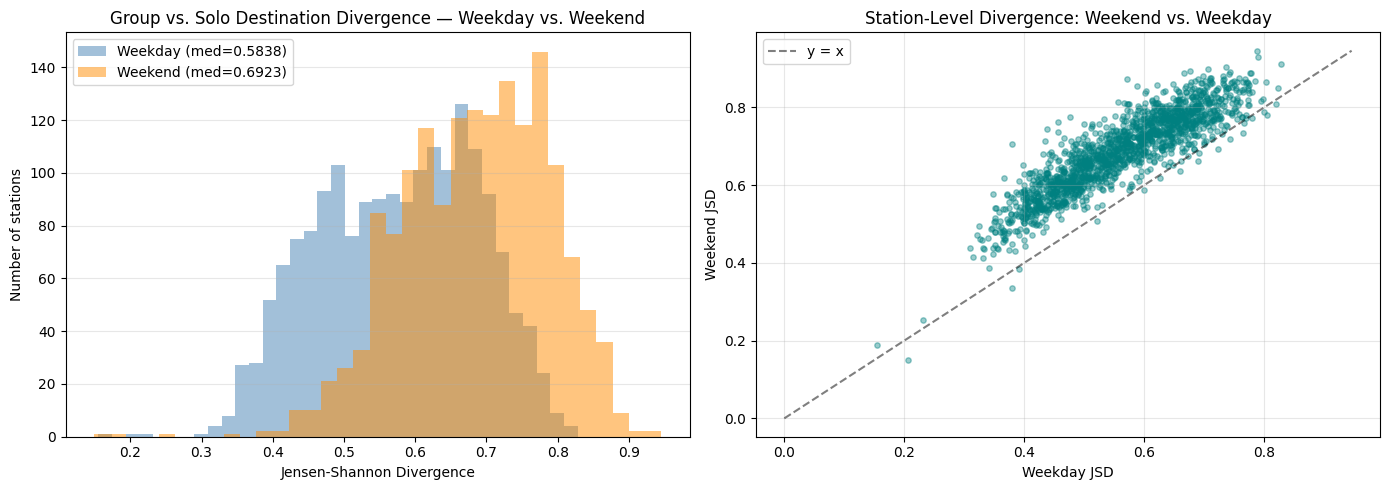

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution comparison
ax = axes[0]
for daytype, color, label in [(0, "steelblue", "Weekday"), (1, "darkorange", "Weekend")]:
    vals = jsd_dt_df[jsd_dt_df["is_weekend"] == daytype]["jsd"]
    ax.hist(vals, bins=35, alpha=0.5, color=color, label=f"{label} (med={vals.median():.4f})")
ax.set_xlabel("Jensen-Shannon Divergence")
ax.set_ylabel("Number of stations")
ax.set_title("Group vs. Solo Destination Divergence — Weekday vs. Weekend")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Paired comparison: for stations present in both, plot weekend JSD vs weekday JSD
pivot_dt = jsd_dt_df.pivot(index="start_station_name", columns="is_weekend", values="jsd").dropna()
pivot_dt.columns = ["weekday_jsd", "weekend_jsd"]

ax = axes[1]
ax.scatter(pivot_dt["weekday_jsd"], pivot_dt["weekend_jsd"], alpha=0.4, s=15, color="teal")
ax.plot([0, pivot_dt.values.max()], [0, pivot_dt.values.max()], "k--", alpha=0.5, label="y = x")
ax.set_xlabel("Weekday JSD")
ax.set_ylabel("Weekend JSD")
ax.set_title("Station-Level Divergence: Weekend vs. Weekday")
ax.legend()
ax.grid(alpha=0.3)

above = (pivot_dt["weekend_jsd"] > pivot_dt["weekday_jsd"]).mean()
print(f"Stations with higher weekend divergence: {above:.1%}")

plt.tight_layout()
plt.show()

## 13. Save divergence scores to Delta

In [0]:
save_df = jsd_full[["start_station_name", "jsd", "n_solo", "n_group",
                     "n_destinations", "archetype", "lat", "lng"]].copy()

sdf_jsd = spark.createDataFrame(save_df)
sdf_jsd.write.format("delta").mode("overwrite").saveAsTable("citibike.station_destination_divergence")
print("Saved citibike.station_destination_divergence ✅")

## Summary

| Finding | Detail |
|---|---|
| Median JSD across stations | 0.548255 |
| % of top stations with significant χ² | 82.0% |
| Archetype with highest divergence | Outer Residential — *expected Tourist/Recreational* |
| Archetype with lowest divergence | Commuter Hub / Commercial Area — *expected Commuter Hub* |
| Weekend vs. weekday | 98.9% |
| System-wide group destination shift | Nightlife / Late Evening {Lift = 1.0396} |

**Interpretation:** Jensen-Shannon divergence quantifies how much social
context reshapes destination choice. High-divergence stations are places
where riding with others leads to fundamentally different trips — typically
near parks, waterfronts, and entertainment districts where groups opt for
scenic/social destinations that solo commuters skip. Low-divergence stations
are dominated by a single strong attractor (e.g. a transit hub) that both
groups and solos funnel toward regardless.

**Next steps:** Join divergence scores back to the co-trip graph to test
whether high-divergence stations also produce longer or shorter group trips,
or feed into the route-choice analysis.